# 1. Iteration Method


### The iteration method is a common approach to find roots of equations. It involves rearranging the equation into the form x = g(x) and then iteratively applying g to an initial guess until convergence.

### Let’s consider the equation x^3 - 4x + 1 = 0. We can rearrange it to x = (x^3 + 1) / 4.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [1]:
def f2(x):
    return x**3 - 2*x + 2

def g2(x):
    return (x**3 + 1) / 4

In [2]:
def iteration_method(g, x, tol=1e-5, max_iter=100):
    for i in range(max_iter):
        x_new = g(x)
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    raise ValueError(
        "Iteration did not converge within the maximum number of iterations."
    )

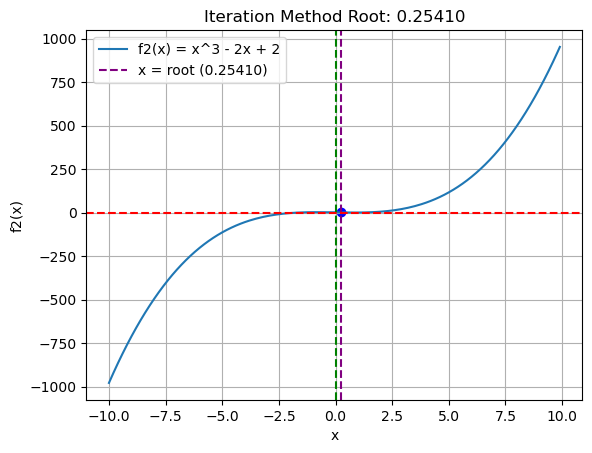

In [5]:
root = iteration_method(g2, 1)

# Let's plot the result
x = np.arange(-10, 10, 0.1)

plt.plot(x, f2(x), label='f2(x) = x^3 - 2x + 2')
plt.scatter(root, f2(root), color='blue')  # Mark the root on the plot
plt.axvline(root, color='purple', linestyle='--', label=f'x = root ({root:.5f})')

plt.axvline(0, color='green', linestyle='--')
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('x')
plt.ylabel('f2(x)')
plt.title(f"Iteration Method Root: {root:.5f}")
plt.grid()
plt.legend()

# 2. Bisection Method

### Bisection method finds the root of a function f in the interval [a, b].

In [9]:
# Function ta define kora
def f(x):
    return x**2 - 2   # ekhane root hobe sqrt(2) ~ 1.4142

# Bisection Method
def bisection_method(f, a, b, tol=1e-5):
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")  

    while (b - a) / 2 > tol:   # jokhon porjonto error tol er cheye boro
        mid = (a + b) / 2.0
        if f(mid) == 0:       # jodi mid e root hoy
            return mid
        elif f(a) * f(mid) < 0:  # root a ar mid er moddhe
            b = mid
        else:                    # root mid ar b er moddhe
            a = mid
    return (a + b) / 2.0   # final root return

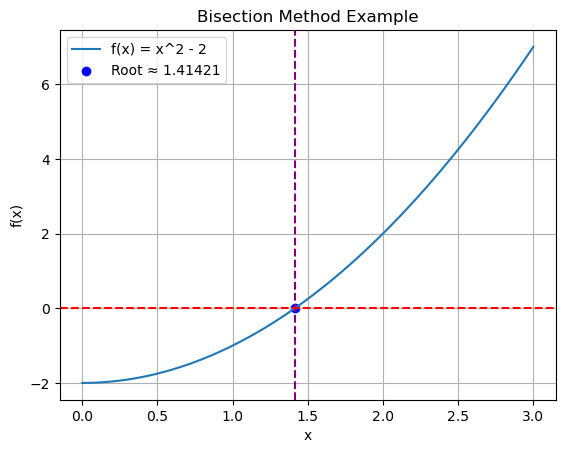

In [10]:
# Root calculate
root = bisection_method(f, 0, 2)  

# Plotting
x = np.linspace(0, 3, 100)
plt.plot(x, f(x), label='f(x) = x^2 - 2')
plt.scatter(root, f(root), color='blue', label=f'Root ≈ {root:.5f}')  
plt.axvline(root, color='purple', linestyle='--')  
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title("Bisection Method Example")
plt.legend()
plt.grid()
plt.show()

# 3. False Position Method

### False Position Method is a root-finding technique where the function values at two points with opposite signs are connected by a straight line.
### The point where this line crosses the x-axis is taken as a new approximation of the root, and the process is repeated until convergence.

In [11]:
# Function define
def f(x):
    return x**2 - 2   # root hobe sqrt(2) ≈ 1.4142

# False Position Method
def false_position(f, a, b, tol=1e-5, max_iter=100):
    for i in range(max_iter):
        c = a - f(a) * (b - a) / (f(b) - f(a))  # formula
        if abs(f(c)) < tol:
            return c
        elif f(a) * f(c) < 0:  # root a & c er moddhe
            b = c
        else:                  # root c & b er moddhe
            a = c
    return c

Root ≈ 1.41421143847487


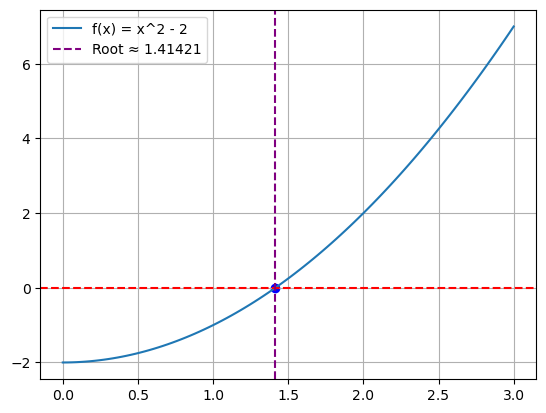

In [12]:
root = false_position(f, 0, 2)
print("Root ≈", root)

# Plot
x = np.linspace(0, 3, 100)
plt.plot(x, f(x), label="f(x) = x^2 - 2")
plt.axhline(0, color="red", linestyle="--")
plt.axvline(root, color="purple", linestyle="--", label=f"Root ≈ {root:.5f}")
plt.scatter(root, f(root), color="blue")
plt.legend()
plt.grid()
plt.show()

# 5. Gauss Elimination

In [18]:
def gaussian_elimination(N, arr):
    a = copy.deepcopy(arr)  # copy.deepcopy ব্যবহার করে original matrix safe রাখা।

    # Forward Elimination
    for i in range(N):
        # Make the pivot = 1
        pivot = a[i][i]
        for j in range(i, N+1):
            a[i][j] /= pivot

        # Make elements below pivot = 0
        for j in range(i+1, N):
            factor = a[j][i]
            for k in range(i, N+1):
                a[j][k] -= factor * a[i][k]

    # Back Substitution
    x = [0 for _ in range(N)]
    for i in range(N-1, -1, -1):
        x[i] = a[i][N]  # Start with RHS
        for j in range(i+1, N):
            x[i] -= a[i][j] * x[j]

    print("Solution:", x)

# Example usage:
N = 3
arr = [
    [2, -1, 1, 3],
    [1, 3, 2, 12],
    [1, -1, 2, 0]
]

gaussian_elimination(N, arr)


Solution: [3.0, 3.0, 0.0]


# 6. Gauss Jordan Elimination

In [27]:
import copy

def print_matrix(mat):
    for row in mat:
        print([int(x) for x in row])
    print()

def gauss_jordan(N, arr):
    a = copy.deepcopy(arr)

    for i in range(N):
        pivot = a[i][i]
        for j in range(N+1):
            a[i][j] /= pivot

        for k in range(N):
            if k != i:
                factor = a[k][i]
                for j in range(N+1):
                    a[k][j] -= factor * a[i][j]

        print_matrix(a)

    solution = [a[i][N] for i in range(N)]
    return solution

N = 3
arr = [[2, 1, -1, 8], [-3, -1, 2, -11], [-2, 1, 2, -3]]
solution = gauss_jordan(N, arr)
print("Solution:", solution)


[1, 0, 0, 4]
[0, 0, 0, 1]
[0, 2, 1, 5]

[1, 0, -1, 3]
[0, 1, 1, 2]
[0, 0, -1, 1]

[1, 0, 0, 2]
[0, 1, 0, 3]
[0, 0, 1, -1]

Solution: [2.0, 3.0, -1.0]


# 8. Least Squares Regression

### Least Squares Regression is a method to find the best-fitting line (or curve) through a set of data points.

## -- Linear Regression

In [31]:
np.random.seed(0)                      # Set seed for reproducibility (same random numbers every run)
x = 2 * np.random.rand(100, 1)         # 100 random numbers between 0 and 2 (column vector)
y = 4 + 3 * x + np.random.randn(100, 1) # Linear relation y = 4 + 3*x + random noise (Gaussian noise)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [36]:
x_new = np.array([[0], [2]])
y_predict = model.predict(x_new)

In [37]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [4.22215108]
Coefficient: [[2.96846751]]


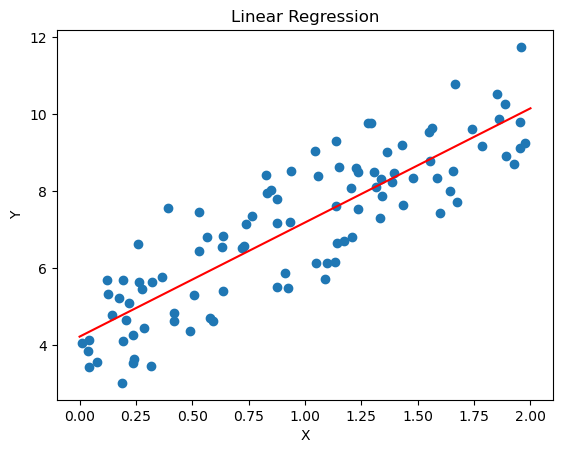

In [38]:
plt.scatter(x, y)
plt.plot(x_new, y_predict, color='red')

plt.xlabel('X')
plt.ylabel('Y')

plt.title('Linear Regression')
plt.show()

# 9.  Logistic Regression

### Logistic Regression is a statistical method used for binary classification, i.e., predicting whether an outcome belongs to one of two categories (like Yes/No, 0/1, True/False).

In [39]:
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'attendance': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
    'pass_exam': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

In [41]:
import pandas as pd

df = pd.DataFrame(data)

In [42]:
df.head()

,hours_studied,attendance,pass_exam
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,0
4,5,70,1


In [43]:
X = df[['hours_studied', 'attendance']].values
y = df['pass_exam'].values

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 2]]


In [51]:
# 7. Test prediction on a new student
new_student = np.array([[4, 68]])  # 4 hours studied, 68% attendance
pred_prob = model.predict_proba(new_student)[0][1]
print(f"Probability of passing:", round(pred_prob, 2))

Probability of passing: 0.23


# 11.  Stochastic Gradient Descent

### Stochastic Gradient Descent (SGD) is a fast optimization method that updates model weights using one data point at a time to minimize error.

In [52]:
np.random.seed(0)
x = 2 * np.random.rand(20, 1)
y = 4 + 3 * x + np.random.randn(20, 1)  # True line: y = 4 + 3x + noise

In [53]:
# 2. SGD parameters
m, c = 0.0, 0.0           # initial guesses
learning_rate = 0.1
epochs = 50
history = []

In [54]:
# 3. SGD iterations
for epoch in range(epochs):
    for i in range(len(x)):
        y_pred = m * x[i] + c
        error = y_pred - y[i]
        m -= learning_rate * error * x[i]   # update slope
        c -= learning_rate * error          # update intercept
    # save m,c for visualization
    history.append([m[0], c[0]])

In [55]:
# 4. Convert history to numpy array
history = np.array(history)

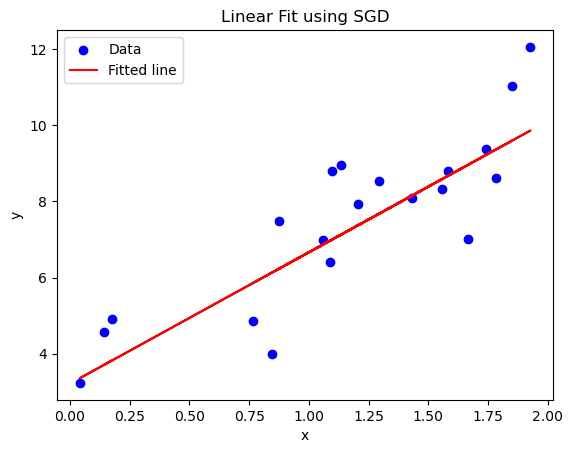

In [56]:
# 5. Plot the data and SGD fitted line
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, m*x + c, color='red', label='Fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Fit using SGD')
plt.legend()
plt.show()

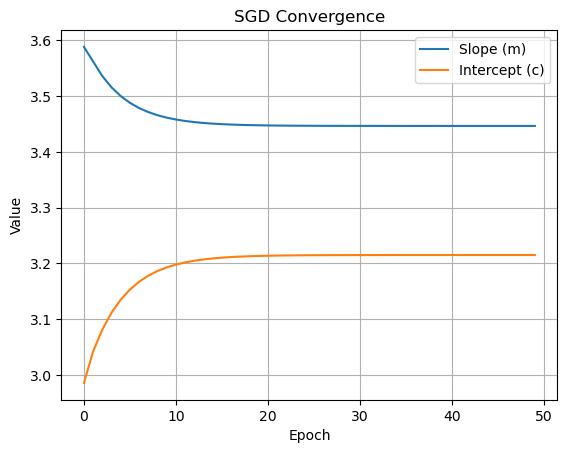

In [57]:
# 6. Visualize convergence of m and c
plt.plot(history[:,0], label='Slope (m)')
plt.plot(history[:,1], label='Intercept (c)')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('SGD Convergence')
plt.legend()
plt.grid()
plt.show()